In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df= pd.read_csv('../dataset/silver_price_forecast_2026.csv')

In [14]:
df.head()

,Date,Predicted_Price,Lower_Bound,Upper_Bound
0,2026-01-02,52.43,48.38,56.64
1,2026-01-05,52.64,48.49,56.84
2,2026-01-06,52.63,48.75,57.01
3,2026-01-07,52.67,48.39,56.62
4,2026-01-08,52.55,48.18,56.60


In [15]:
df.shape

(85, 4)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             85 non-null     object 
 1   Predicted_Price  85 non-null     float64
 2   Lower_Bound      85 non-null     float64
 3   Upper_Bound      85 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.8+ KB


In [18]:
df.columns

Index(['Date', 'Predicted_Price', 'Lower_Bound', 'Upper_Bound'], dtype='object')

In [20]:
df.isna().sum()

Date               0
Predicted_Price    0
Lower_Bound        0
Upper_Bound        0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.describe()

,Predicted_Price,Lower_Bound,Upper_Bound
count,85.000000,85.000000,85.000000
mean,51.105412,46.919529,55.255882
std,0.932131,0.946931,0.984584
min,48.960000,44.570000,52.880000
25%,50.350000,46.190000,54.600000
50%,51.270000,46.990000,55.380000
75%,51.750000,47.620000,55.920000
max,52.670000,48.750000,57.010000


In [31]:
df['Date'] = pd.to_datetime(df['Date'])

df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.day_name()

In [23]:
# EDA

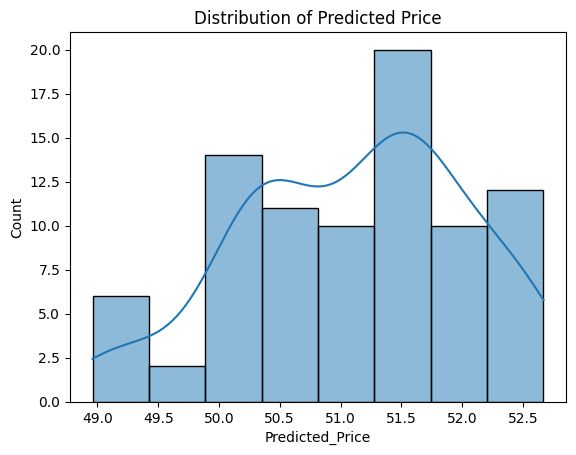

In [47]:
sns.histplot(df['Predicted_Price'], kde=True)
plt.title("Distribution of Predicted Price")
plt.show()

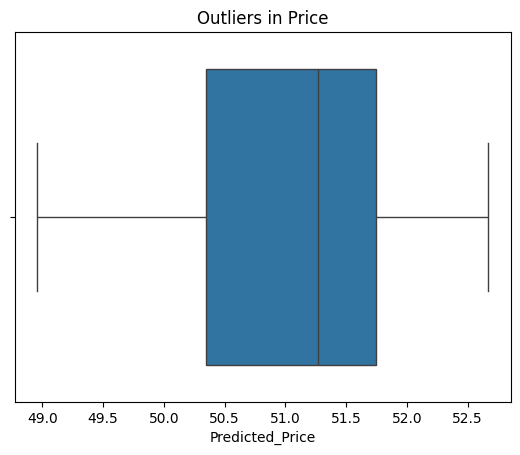

In [33]:
sns.boxplot(x=df['Predicted_Price'])
plt.title("Outliers in Price")
plt.show()

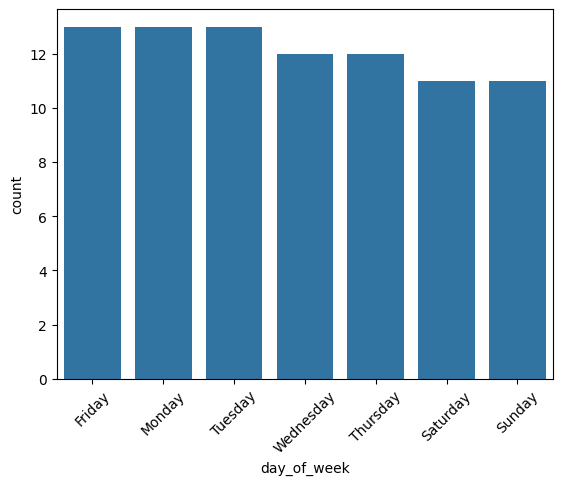

In [34]:
sns.countplot(x='day_of_week', data=df)
plt.xticks(rotation=45)
plt.show()

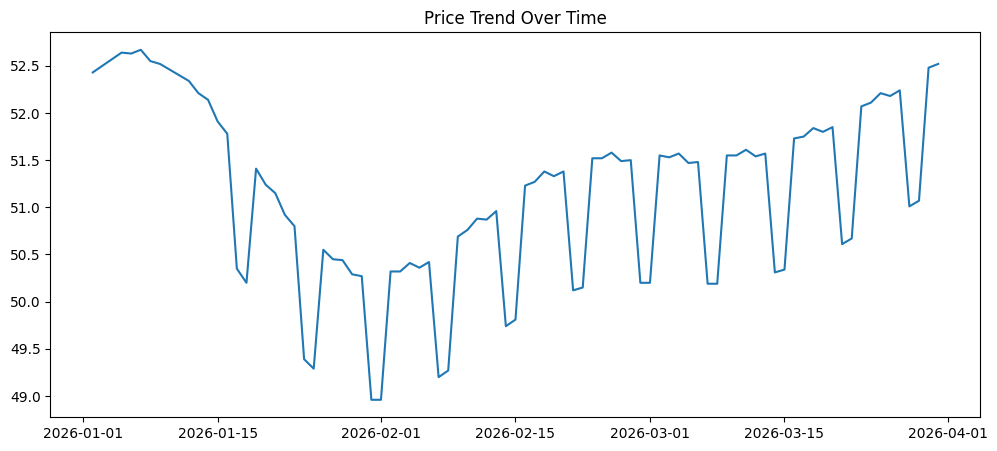

In [35]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Predicted_Price'])
plt.title("Price Trend Over Time")
plt.show()

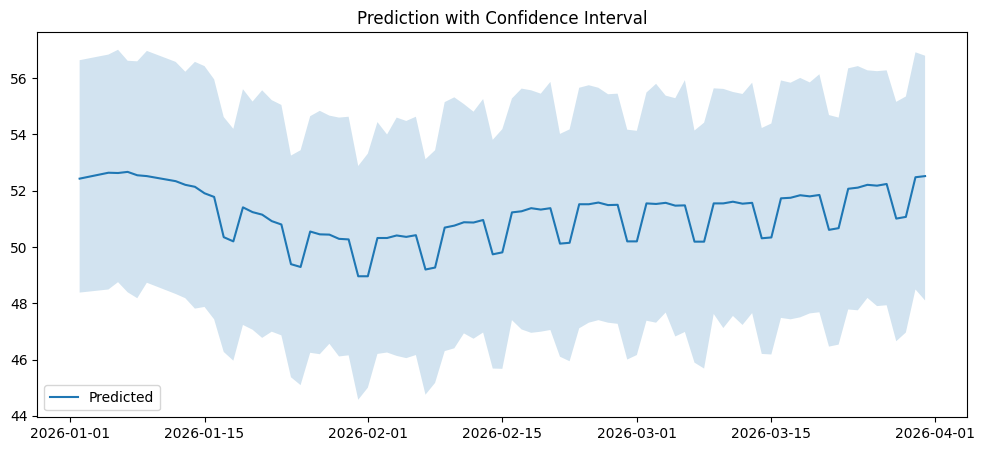

In [36]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Predicted_Price'], label='Predicted')
plt.fill_between(df['Date'], df['Lower_Bound'], df['Upper_Bound'], alpha=0.2)

plt.legend()
plt.title("Prediction with Confidence Interval")
plt.show()

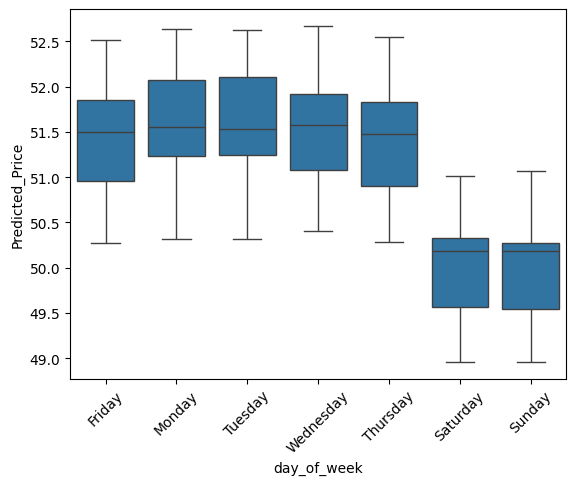

In [37]:
sns.boxplot(x='day_of_week', y='Predicted_Price', data=df)
plt.xticks(rotation=45)
plt.show()

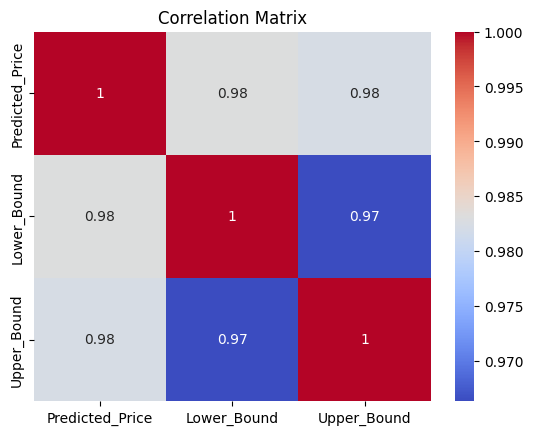

In [38]:
corr = df[['Predicted_Price','Lower_Bound','Upper_Bound']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

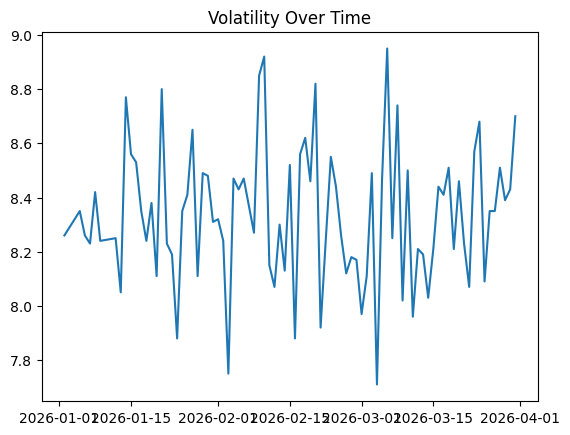

In [39]:
df['volatility'] = df['Upper_Bound'] - df['Lower_Bound']

plt.plot(df['Date'], df['volatility'])
plt.title("Volatility Over Time")
plt.show()

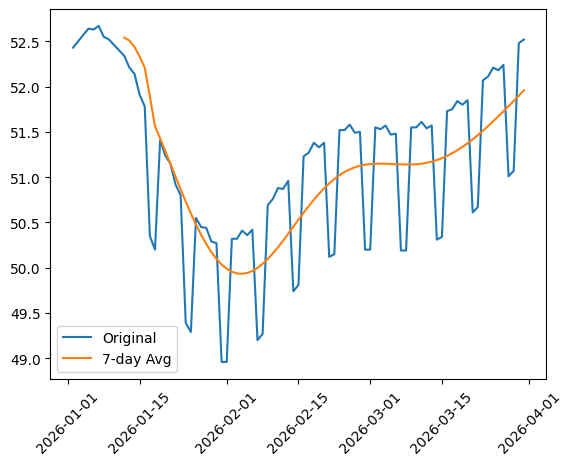

In [41]:
df['rolling_mean_7'] = df['Predicted_Price'].rolling(7).mean()

plt.plot(df['Date'], df['Predicted_Price'], label='Original')
plt.plot(df['Date'], df['rolling_mean_7'], label='7-day Avg')
plt.xticks(rotation=45)

plt.legend()
plt.show()

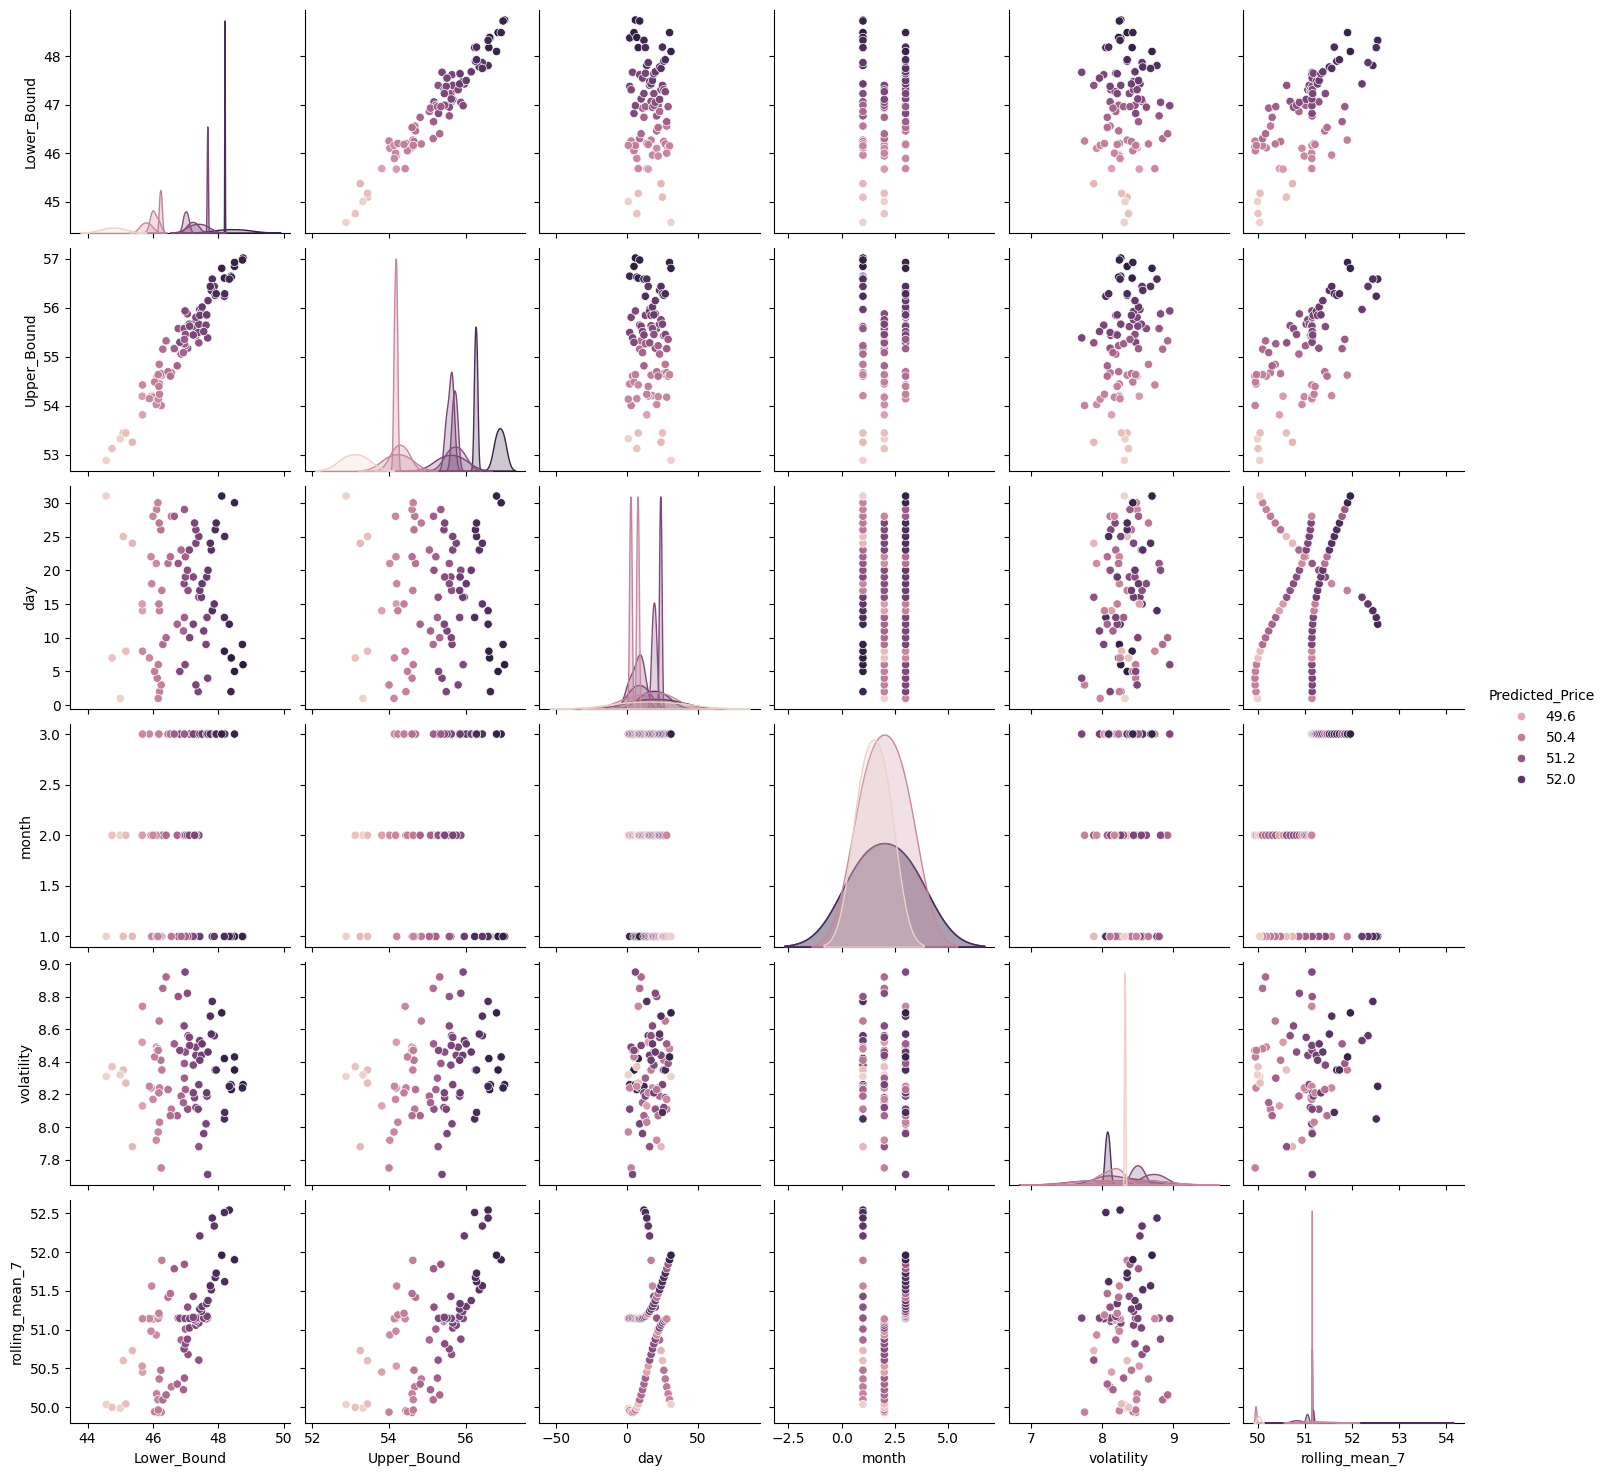

In [50]:
sns.pairplot(data=df,hue='Predicted_Price')

In [43]:
df

,Date,Predicted_Price,Lower_Bound,Upper_Bound,day,month,day_of_week,volatility,rolling_mean_7
0,2026-01-02,52.43,48.38,56.64,2,1,Friday,8.26,NaN
1,2026-01-05,52.64,48.49,56.84,5,1,Monday,8.35,NaN
2,2026-01-06,52.63,48.75,57.01,6,1,Tuesday,8.26,NaN
3,2026-01-07,52.67,48.39,56.62,7,1,Wednesday,8.23,NaN
4,2026-01-08,52.55,48.18,56.60,8,1,Thursday,8.42,NaN
...,...,...,...,...,...,...,...,...,...
80,2026-03-27,52.24,47.93,56.28,27,3,Friday,8.35,51.727143
81,2026-03-28,51.01,46.65,55.16,28,3,Saturday,8.51,51.784286
82,2026-03-29,51.07,46.96,55.35,29,3,Sunday,8.39,51.841429
83,2026-03-30,52.48,48.49,56.92,30,3,Monday,8.43,51.900000


In [46]:
df.to_csv('../dataset/after-eda.csv', index=False)